<a href="https://colab.research.google.com/github/sergiomora03/AdvancedTopicsAnalytics/blob/main/E5-Neural NetworksinKerasforNLP/E5_NeuralNetworksKerasNLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Excercise 5
## NLP with Keras

Use keras framework to solve the below exercises.


In [14]:
import numpy as np
import keras
import pandas as pd
import matplotlib.pyplot as plt

## 5.1 Predict rating of a movie using Keras

**Exercise:** Use keras framework to predict rating.

In [15]:
dataTraining = pd.read_csv('https://github.com/sergiomora03/AdvancedTopicsAnalytics/raw/main/datasets/dataTraining.zip', encoding='UTF-8', index_col=0)

In [16]:
plots = dataTraining['plot']
y = (dataTraining['rating'] >= dataTraining['rating'].mean()).astype(int)

In [17]:
plots

,plot
3107,most is the story of a single father who takes...
900,a serial killer decides to teach the secrets o...
6724,"in sweden , a female blackmailer with a disfi..."
4704,"in a friday afternoon in new york , the presi..."
2582,"in los angeles , the editor of a publishing h..."
...,...
8417,""" our marriage , their wedding . "" it ' s l..."
1592,"the wandering barbarian , conan , alongside ..."
1723,"like a tale spun by scheherazade , kismet fol..."
7605,"mrs . brisby , a widowed mouse , lives in a..."


In [18]:
y

,rating
3107,1
900,0
6724,1
4704,1
2582,1
...,...
8417,0
1592,0
1723,0
7605,1


## Data Precosessing

- Remove stopwords
- Lowercase
- split the text in words
- pad_sequences

In [19]:
!pip install nltk tensorflow

In [20]:
import nltk
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [21]:
import pandas as pd
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from tensorflow.keras.layers import Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [22]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = ''.join([word for word in text if word not in string.punctuation])
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

In [23]:
cleaned_plots = plots.apply(preprocess_text)
print(cleaned_plots[0])
print(plots[0])

major benson winifred payne discharged marines payne killin machine wars world longer fought battlefield career marine idea civilian commander finds job commanding officer local school jrotc program bunch ragtag losers hope using teaching tools live grenades real bullets payne starts instill corp hope payne recalled fight bosnia leave corp started believe find killin much livin
major benson winifred payne is being discharged from the marines .  payne is a killin '  machine ,  but the wars of the world are no longer fought on the battlefield .  a career marine ,  he has no idea what to do as a civilian ,  so his commander finds him a job  -  commanding officer of a local school ' s jrotc program ,  a bunch or ragtag losers with no hope .  using such teaching tools as live grenades and real bullets ,  payne starts to instill the corp with some hope .  but when payne is recalled to fight in bosnia ,  will he leave the corp that has just started to believe in him ,  or will he find out tha

In [26]:
 X = cleaned_plots.tolist()
# For vocabulary only the intersec characters is used to avoid issues with data collection
voc = set(''.join(X))
vocabulary = {x: idx + 1 for idx, x in enumerate(set(voc))}

In [29]:
# Max len
max_len = 150

tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(cleaned_plots)
sequences = tokenizer.texts_to_sequences(cleaned_plots)
# OOV tokens get index 1, which is < 10000, so no problem
X = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')


y = np.array(y)

In [30]:
#X_pad = pad_sequences(X, maxlen=max_len)

padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')
print(padded_sequences.shape)
print(padded_sequences[0])

(7895, 150)
[  38  529   12   61  945   43   16   39   49 3259    1 2414 7734   34
  100   50   36 2684  319  195    1 2414   12   55 4773  276   76   39
  257 1995 1197 1198  326   88 2414    1  360 1286  812 1742   84  319
  570  812   39  132   71 4054   12  160   97 9988  319 2415   39  148
    1 6771  175 2846 3166 2414  454   12 2756  971   12    1 2414    1
 6772  100   45  319 1128 6773  445  100  489  109  158  195 3446   36
  578  302  319 1821  140  308    6 4055    5   58   50   36 1002  195
 3446 2208  113  340    1    1  170 5711 1822    3  543  195 3446  128
 4967 8365   70    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0]


## Build Model

Create a neural network to predict the rating of a movie, calculate the testing set accuracy.

In [31]:
y = np.array(y)

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


In [32]:
model = Sequential([
    Embedding(input_dim=10000, output_dim=32, input_length=max_len),
    GlobalAveragePooling1D(),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy',
              optimizer=Adam(1e-3),
              metrics=['accuracy'])
model.summary()


history = model.fit(X_train, y_train, epochs=10, batch_size=128, validation_split=0.1)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5300 - loss: 0.6921 - val_accuracy: 0.5538 - val_loss: 0.6867
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5581 - loss: 0.6821 - val_accuracy: 0.5807 - val_loss: 0.6780
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5954 - loss: 0.6709 - val_accuracy: 0.5823 - val_loss: 0.6699
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5929 - loss: 0.6671 - val_accuracy: 0.5981 - val_loss: 0.6714
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6179 - loss: 0.6520 - val_accuracy: 0.6108 - val_loss: 0.6605
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6638 - loss: 0.6247 - val_accuracy: 0.6155 - val_loss: 0.6563
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6971 - loss: 0.5977 - val_accuracy: 0.6297 - val_loss: 0.6514
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7533 - loss: 0.5607 - val_accuracy: 0.6440 - val

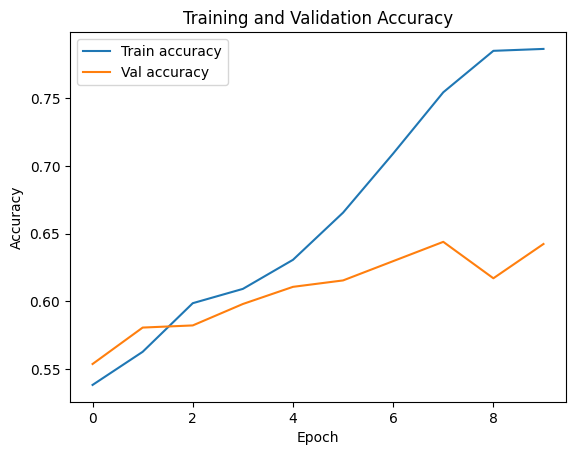

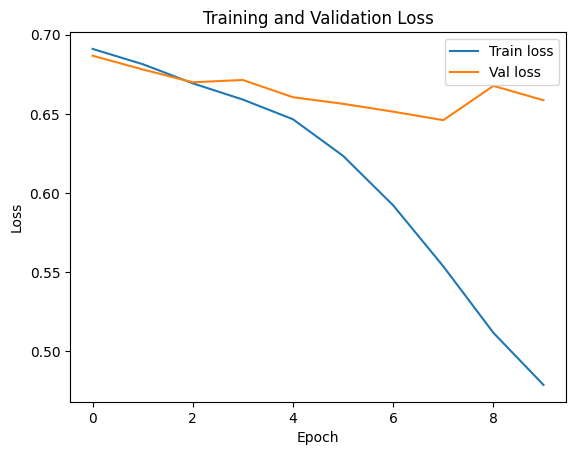

In [33]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train accuracy')
plt.plot(history.history['val_accuracy'], label='Val accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Pérdida (loss)
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Test accuracy: 0.6510


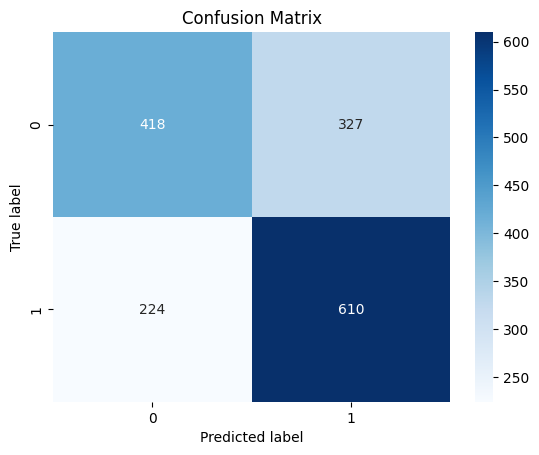

              precision    recall  f1-score   support

           0       0.65      0.56      0.60       745
           1       0.65      0.73      0.69       834

    accuracy                           0.65      1579
   macro avg       0.65      0.65      0.65      1579
weighted avg       0.65      0.65      0.65      1579

Rating real: 0, predicción: 1
---
Rating real: 0, predicción: 1
---
Rating real: 0, predicción: 1
---
Rating real: 0, predicción: 1
---
Rating real: 1, predicción: 0
---
Rating real: 1, predicción: 1
---
Rating real: 0, predicción: 1
---
Rating real: 0, predicción: 0
---
Rating real: 0, predicción: 0
---
Rating real: 1, predicción: 1
---
Rating real: 1, predicción: 0
---
Rating real: 1, predicción: 1
---
Rating real: 0, predicción: 0
---
Rating real: 1, predicción: 1
---
Rating real: 0, predicción: 1
---
Rating real: 1, predicción: 1
---
Rating real: 0, predicción: 0
---
Rating real: 0, predicción: 0
---
Rating real: 1, predicción: 1
---
Rating real: 0, predicción:

In [34]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# Calcular predicciones
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

# Imprimir accuracy
accuracy = (y_pred == y_test).mean()
print(f'Test accuracy: {accuracy:.4f}')

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()

# Reporte de clasificación
print(classification_report(y_test, y_pred))

# Probar algunas predicciones concretas
for i in range(20):
    print(f"Rating real: {y_test[i]}, predicción: {y_pred[i]}")
    print('---')